In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [51]:
data = pd.read_csv('../data/data1.csv')

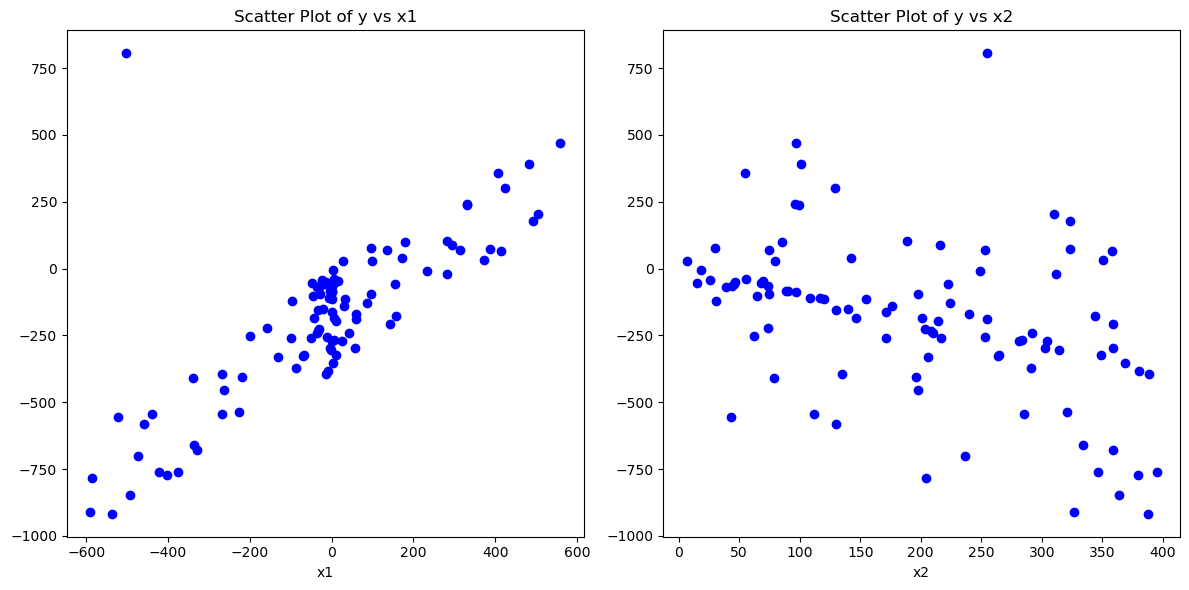

In [52]:
plt.figure(figsize=(12,6))

for i, x in enumerate(['x1', 'x2']):
    plt.subplot(1, 2, i+1)
    plt.scatter(data[x], data['y'], color='blue', label='Data Points')
    plt.xlabel(x)
    plt.title(f'Scatter Plot of y vs {x}')

plt.tight_layout()
plt.show()

Prosty rysnek y(x1) i y(x2) sugerują, że istnieje jakaś liniowa zależność, z tym że w drugim przypadku wariancja raczej większa

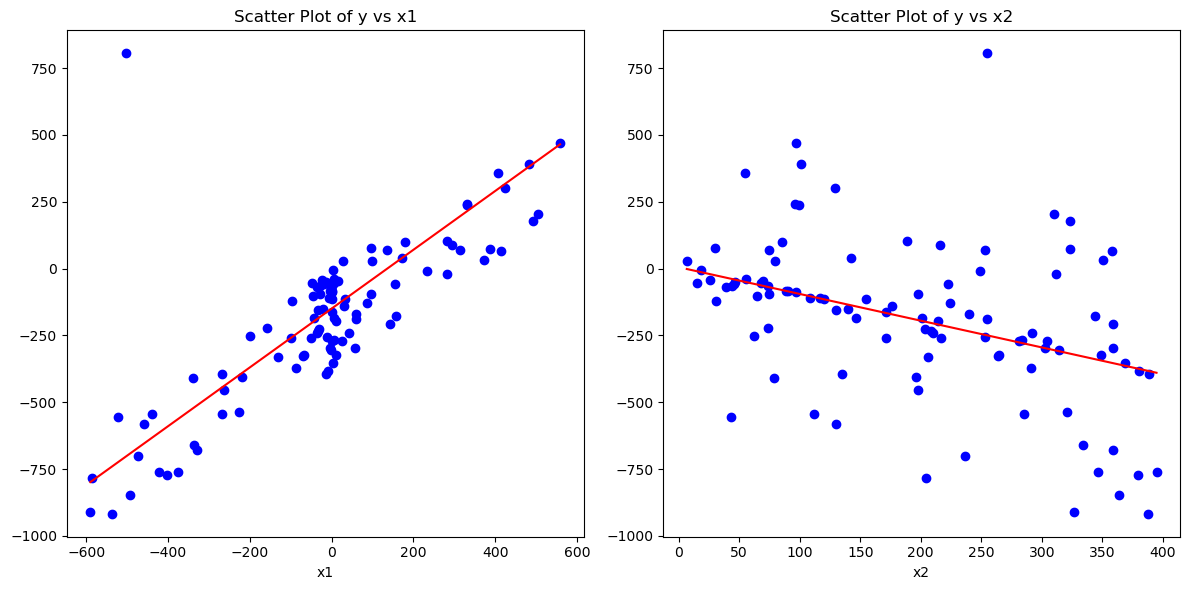

In [53]:
plt.figure(figsize=(12,6))

a = {'x1': 1.1, 'x2': -1.0}
b = {'x1': -150, 'x2': 5.0}

for i, x in enumerate(['x1', 'x2']):
    plt.subplot(1, 2, i+1)
    plt.scatter(data[x], data['y'], color='blue', label='Data Points')
    plt.xlabel(x)
    plt.title(f'Scatter Plot of y vs {x}')

    x_linia = np.array([data[x].min(), data[x].max()])
    y_linia = a[x] * x_linia + b[x]

    plt.plot(x_linia, y_linia, color='red', label=f'Linia: y = {a[x]}*x + {b[x]}')

plt.tight_layout()
plt.show()

Tutaj przykładowej naniesienie prostych na dane.

Teraz trzeba przygotować dane do modelowania. Regresja liniowa zdaje się być odpowiednia.

In [54]:
from sklearn.preprocessing import StandardScaler

def preprocess_data(X_train, y_train):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    return X_train_scaled, y_train, scaler

In [55]:
X_scaled, y_scaled, scaler = preprocess_data(data[['x1', 'x2']], data['y'])

In [56]:
print(f"Średnia (x1, x2): {scaler.mean_}")
print(f"Odchylenie standardowe (x1, x2): {scaler.scale_}")

Średnia (x1, x2): [-16.51645199 194.78741033]
Odchylenie standardowe (x1, x2): [250.56668511 113.59153082]


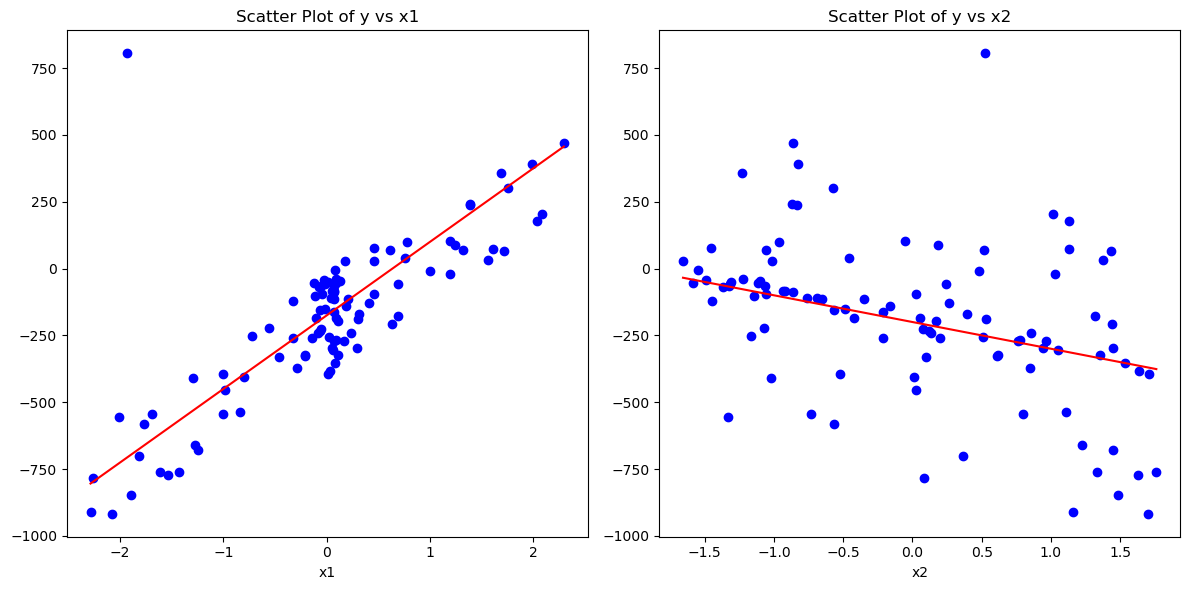

In [71]:
plt.figure(figsize=(12,6))

a = {'x1': 275, 'x2': -100.0}
b = {'x1': -175, 'x2': -200.0}

for i, x in enumerate(['x1', 'x2']):
    plt.subplot(1, 2, i+1)
    plt.scatter(X_scaled[:, i], y_scaled, color='blue', label='Data Points')
    plt.xlabel(x)
    plt.title(f'Scatter Plot of y vs {x}')

    x_linia = np.array([X_scaled[:, i].min(), X_scaled[:, i].max()])
    y_linia = a[x] * x_linia + b[x]

    plt.plot(x_linia, y_linia, color='red', label=f'Linia: y = {a[x]}*x + {b[x]}')

plt.tight_layout()
plt.show()